[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/04_efficientnet_b0.ipynb)

# EfficientNet-B0

**CSC3109 - Machine Learning | Team 16 — Haley**

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally — skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED, TRAIN_RATIO
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Split  : {TRAIN_RATIO:.0%} train / {1-TRAIN_RATIO:.0%} val")
print("Policy : 70/30 split inside each class folder in data/set 16")

ROOT   : /content/CSC3109-T16-Project
Device : cuda
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Split  : 70% train / 30% val
Policy : 70/30 split inside each class folder in data/set 16


## 1. Data Loading
 The dataloader applies the shared project split: a 70/30 split inside each class folder in `data/set 16`. This keeps every class at 490 train and 210 validation images.

In [3]:
from src.dataset import get_dataloaders

train_loader, val_loader, classes = get_dataloaders(
    root        = ROOT,
    data_dir    = DATA_DIR,
    batch_size  = BATCH_SIZE,
    image_size  = IMAGE_SIZE,
    train_ratio = TRAIN_RATIO,
    seed        = SEED,
    num_workers = 2,
)

def subset_class_counts(subset, class_names):
    targets = subset.dataset.targets
    counts = {cls: 0 for cls in class_names}
    for idx in subset.indices:
        counts[class_names[targets[idx]]] += 1
    return counts

print(f"Classes       : {classes}")
print(f"Split policy  : {TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%} inside each class folder")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} images)")
print(f"Train counts  : {subset_class_counts(train_loader.dataset, classes)}")
print(f"Val counts    : {subset_class_counts(val_loader.dataset, classes)}")

Classes       : ['beach', 'ferry_terminal', 'harbor', 'river']
Split policy  : 70%/30% inside each class folder
Train batches : 62  (1960 images)
Val batches   : 27  (840 images)
Train counts  : {'beach': 490, 'ferry_terminal': 490, 'harbor': 490, 'river': 490}
Val counts    : {'beach': 210, 'ferry_terminal': 210, 'harbor': 210, 'river': 210}


##1b. Perceptual Hash
A perceptual hash (pHash) check was performed to verify that there were no exact or near-identical images shared between the training and validation sets, reducing the risk of data leakage and ensuring a fair evaluation.

In [4]:
!pip install imagehash -q

import imagehash
from PIL import Image

def hash_paths(subset, class_names):
    hashes = {}
    for idx in subset.indices:
        path, target = subset.dataset.samples[idx]
        h = imagehash.phash(Image.open(path))
        hashes[str(h)] = (path, class_names[target])
    return hashes

train_hashes = hash_paths(train_loader.dataset, classes)
val_hashes   = hash_paths(val_loader.dataset, classes)

overlap = set(train_hashes) & set(val_hashes)
print(f"Exact/near-identical hash matches between train and val: {len(overlap)}")
for h in list(overlap)[:10]:
    print(train_hashes[h], "<->", val_hashes[h])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.7 MB/s eta 0:00:00
Exact/near-identical hash matches between train and val: 0


## 2. Model Setup
EfficientNet-B0 was selected as one of the models evaluated in this project. ImageNet pretrained weights were used, and the final classification layer was replaced to output the four scene classes. During Phase 1, the backbone was kept frozen so that only the new classifier was trained before fine-tuning the entire model in Phase 2.

In [5]:
from src.models import get_efficientnet_b0
from src.utils import count_parameters

model = get_efficientnet_b0(num_classes=NUM_CLASSES, pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model = model.to(DEVICE)

total_params = count_parameters(model)
print(f"Trainable parameters (Phase 1 - head only) : {total_params / 1e6:.4f} M")
print(f"Model head                                  : {model.classifier}")
print(f"Running on                                  : {DEVICE}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s]


Trainable parameters (Phase 1 — head only) : 0.0051 M
Model head                                  : Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
Running on                                  : cuda


## 3. Training the model
EfficientNet-B0 was trained in 2 phases.

Phase 1: Only the new classification head was trained while the pretrained backbone remained frozen. This allows the new classifier to learn first without changing the pretrained features too quickly.

Phase 2: The backbone was unfrozen and the whole model was fine-tuned using a learning rate that was lower together with CosineAnnealingLR. This helps the pretrained features to adapt gradually to the dataset.

Since `train()` resets the best validation accuracy each time it is called, each phase saves its own checkpoint. After training, the checkpoint with the higher validation accuracy is selected as the final model.

### 3a. Phase 1: Frozen backbone

In [6]:
import torch
from src.train import train

SAVE_PATH_P1 = ROOT / "results" / "saved_models" / "efficientnet_b0_phase1.pth"
PHASE1_EPOCHS = 8

optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
)

history_p1 = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_p1,
    scheduler=None,
    num_epochs=PHASE1_EPOCHS,
    device=DEVICE,
    save_path=SAVE_PATH_P1,
)

Epoch [01/8]  train loss: 0.5706  train acc: 0.8796  val loss: 0.2848  val acc: 0.9488  (18.2s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase1.pth  (val_acc=0.9488)
Epoch [02/8]  train loss: 0.2108  train acc: 0.9546  val loss: 0.1862  val acc: 0.9607  (13.5s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase1.pth  (val_acc=0.9607)
Epoch [03/8]  train loss: 0.1791  train acc: 0.9469  val loss: 0.1565  val acc: 0.9655  (12.6s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase1.pth  (val_acc=0.9655)
Epoch [04/8]  train loss: 0.1361  train acc: 0.9633  val loss: 0.1438  val acc: 0.9631  (13.5s)
Epoch [05/8]  train loss: 0.1362  train acc: 0.9536  val loss: 0.1221  val acc: 0.9690  (12.5s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase1.pth  (val_acc=0.9690)
Epoch [06/8]  train loss: 0.1256  train 

### 3b. Phase 2: Unfreeze and fine-tune

In [7]:
SAVE_PATH_P2 = ROOT / "results" / "saved_models" / "efficientnet_b0_phase2.pth"
PHASE2_EPOCHS = 12

for param in model.features.parameters():
    param.requires_grad = True

print(f"Trainable parameters (Phase 2 — full network) : {count_parameters(model) / 1e6:.4f} M")

optimizer_p2 = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS)

history_p2 = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_p2,
    scheduler=scheduler_p2,
    num_epochs=PHASE2_EPOCHS,
    device=DEVICE,
    save_path=SAVE_PATH_P2,
)

Trainable parameters (Phase 2 — full network) : 4.0127 M
Epoch [01/12]  train loss: 0.0819  train acc: 0.9714  val loss: 0.0636  val acc: 0.9798  (14.8s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase2.pth  (val_acc=0.9798)
Epoch [02/12]  train loss: 0.0680  train acc: 0.9760  val loss: 0.0945  val acc: 0.9881  (14.8s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase2.pth  (val_acc=0.9881)
Epoch [03/12]  train loss: 0.0426  train acc: 0.9862  val loss: 0.0246  val acc: 0.9964  (16.1s)
  -> Best model saved to /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0_phase2.pth  (val_acc=0.9964)
Epoch [04/12]  train loss: 0.0361  train acc: 0.9883  val loss: 0.0532  val acc: 0.9929  (15.3s)
Epoch [05/12]  train loss: 0.0351  train acc: 0.9867  val loss: 0.0262  val acc: 0.9905  (14.6s)
Epoch [06/12]  train loss: 0.0274  train acc: 0.9898  val loss: 0.1781  val acc: 0.9881  (14.7s)
E

### 3c. Select best checkpoint

In [8]:
import shutil

SAVE_PATH = ROOT / "results" / "saved_models" / "efficientnet_b0.pth"
best_p1 = max(history_p1["val_acc"])
best_p2 = max(history_p2["val_acc"])

if best_p2 >= best_p1:
    shutil.copy(SAVE_PATH_P2, SAVE_PATH)
    print(f"Using Phase 2 checkpoint (val_acc={best_p2:.4f})")
else:
    shutil.copy(SAVE_PATH_P1, SAVE_PATH)
    print(f"Using Phase 1 checkpoint (val_acc={best_p1:.4f}): Fine-tuning did not help")

print("Training done.")
print("Best model saved to:", SAVE_PATH)


Using Phase 2 checkpoint (val_acc=0.9964)
Training done.
Best model saved to: /content/CSC3109-T16-Project/results/saved_models/efficientnet_b0.pth


## 4. Training Curves
Loss and accuracy plotted over epochs for both train and val splits, combining Phase 1 and Phase 2 into one continuous curve. The visible change at the phase boundary (epoch 8→9) is the empirical evidence for the two-phase choice.

Training curves saved to /content/CSC3109-T16-Project/results/training_curves/efficientnet_b0_training_curve.png


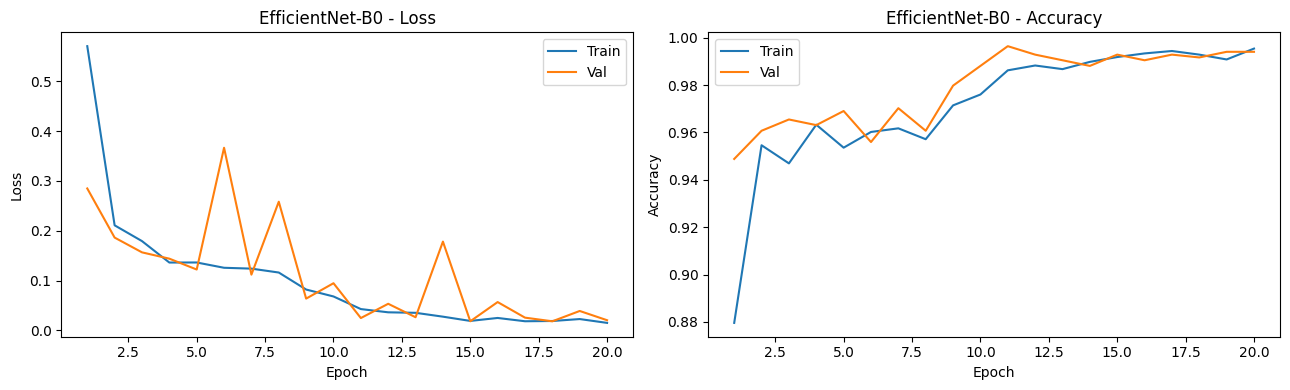

In [9]:
from src.utils import plot_training_curves

history = {key: history_p1[key] + history_p2[key] for key in history_p1}

CURVES_PATH = ROOT / "results" / "training_curves" / "efficientnet_b0_training_curve.png"

plot_training_curves(history, title="EfficientNet-B0", save_path=CURVES_PATH)


## 5. Evaluation
Loads the best checkpoint saved during training and runs inference on the full val set to get the final accuracy, precision, recall, and F1 score.

In [10]:
import torch
from src.evaluate import get_predictions, compute_metrics, print_report

# Load best saved weights before evaluating
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

y_pred, y_true = get_predictions(model, val_loader, DEVICE)
metrics        = compute_metrics(y_true, y_pred)

print("=" * 40)
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print("=" * 40)
print()
print_report(y_true, y_pred, CLASS_NAMES)

  Accuracy  : 0.9964
  Precision : 0.9965
  Recall    : 0.9964
  F1 Score  : 0.9964

                precision    recall  f1-score   support

         beach       1.00      1.00      1.00       210
ferry_terminal       1.00      0.99      0.99       210
        harbor       0.99      1.00      1.00       210
         river       1.00      1.00      1.00       210

      accuracy                           1.00       840
     macro avg       1.00      1.00      1.00       840
  weighted avg       1.00      1.00      1.00       840



## 6. Confusion Matrix
Shows which classes the model confuses most often. Off-diagonal entries highlight where misclassifications are concentrated

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/efficientnet_b0_confusion_matrix.png


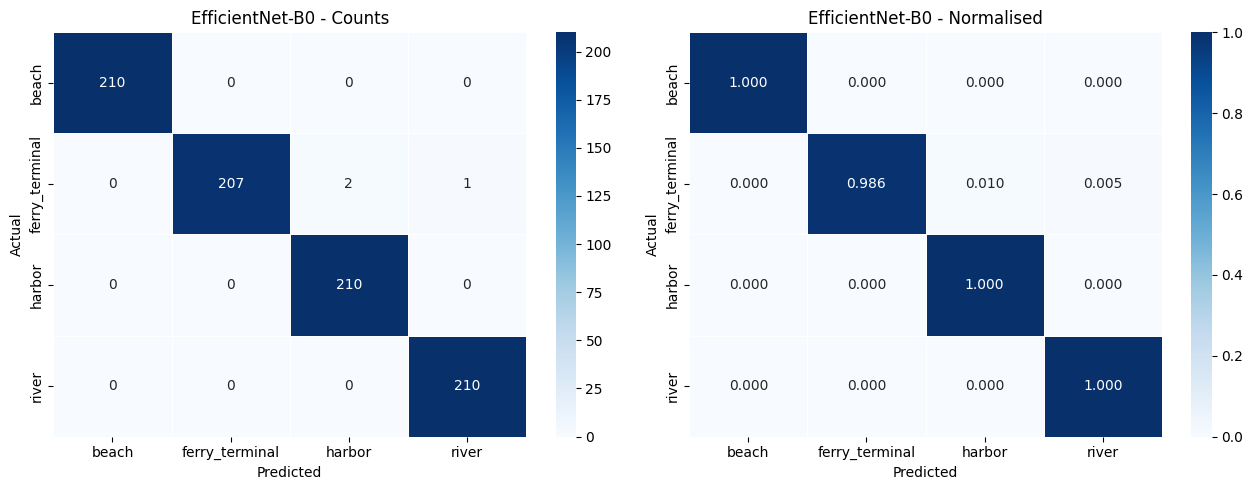

In [11]:
from src.evaluate import plot_confusion_matrix

CM_PATH = ROOT / "results" / "confusion_matrices" / "efficientnet_b0_confusion_matrix.png"

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title="EfficientNet-B0", save_path=CM_PATH)

## 7. Save Metrics
 Writes this model's results to the shared `results/metrics.csv`

In [12]:
from src.utils import save_metrics_to_csv

METRICS_PATH = ROOT / "results" / "metrics.csv"

save_metrics_to_csv("efficientnet_b0", metrics, METRICS_PATH)
print("Results written to results/metrics.csv")

Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Results written to results/metrics.csv


## 8. Sample Predictions
Randomly samples two images per class from the val set and runs them through the model. Green titles are correct predictions, red are misclassifications.


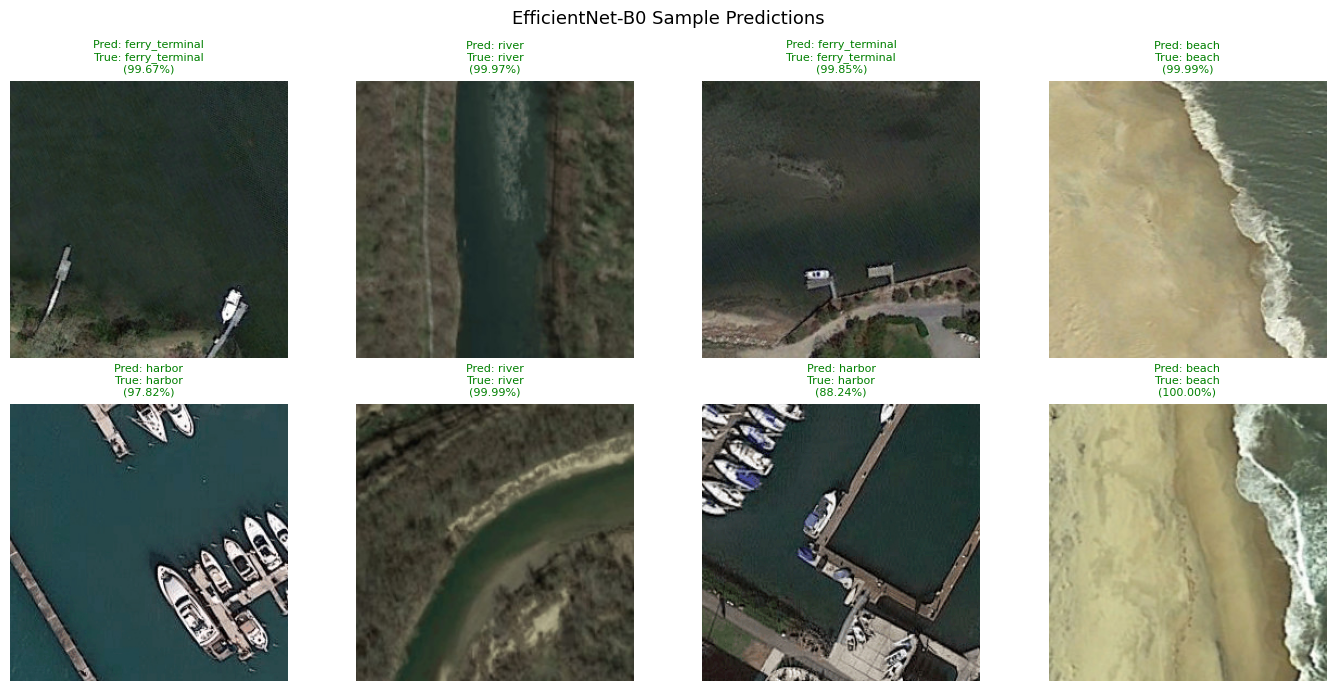

In [13]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from src.predict import predict_image

val_subset = val_loader.dataset
val_paths_by_class = {cls: [] for cls in classes}
for idx in val_subset.indices:
    path, target = val_subset.dataset.samples[idx]
    val_paths_by_class[classes[target]].append(Path(path))

sample_paths = []
for cls in classes:
    imgs = val_paths_by_class[cls]
    sample_paths.extend(random.sample(imgs, min(2, len(imgs))))

random.shuffle(sample_paths)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("EfficientNet-B0 Sample Predictions", fontsize=13)

for ax, path in zip(axes.flat, sample_paths[:8]):
    label, conf, _ = predict_image(path, model, classes, DEVICE, IMAGE_SIZE)
    true_cls = path.parent.name
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    color = "green" if label == true_cls else "red"
    title = f"Pred: {label}\nTrue: {true_cls}\n({conf:.2%})"
    ax.set_title(title, fontsize=8, color=color)

plt.tight_layout()
plt.show()

## 9. Qualitative Error Analysis
A sample of misclassified validation images, to inspect whether errors cluster around visually similar classes.

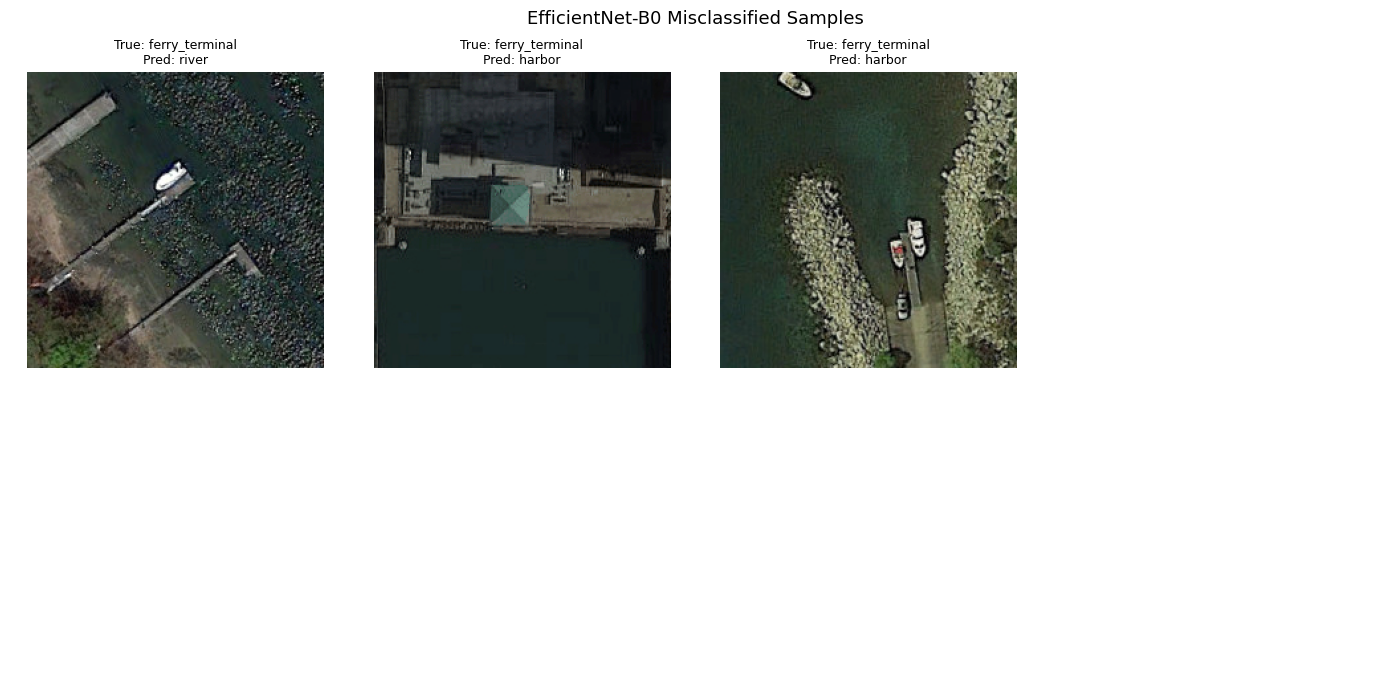

In [14]:
import numpy as np

wrong_idx = np.where(y_pred != y_true)[0]
n_show = min(8, len(wrong_idx))
sample_idx = np.random.RandomState(SEED).choice(wrong_idx, size=n_show, replace=False)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("EfficientNet-B0 Misclassified Samples", fontsize=13)

for ax, idx in zip(axes.flat, sample_idx):
    img, label = val_loader.dataset[idx]
    img = img.permute(1, 2, 0).numpy() * std + mean
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"True: {classes[y_true[idx]]}\nPred: {classes[y_pred[idx]]}", fontsize=9)
    ax.axis("off")

for ax in axes.flat[len(sample_idx):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(ROOT / "results" / "confusion_matrices" / "efficientnet_b0_misclassified.png", bbox_inches="tight")
plt.show()